Illustration of tracts' preprocessing pipeline

In [1]:
import numpy as np
from dipy.io.streamline import load_tractogram
from coloraide import Color
import matplotlib.pylab as pl
import subprocess

from dipy.io.utils import Space

In [2]:
path='/home/gui/Documents/Post-doc/code/TractOT/data/'
subject='000000'

# 23 Reordering

In [3]:
cmd='cd .. && '
cmd+='cd preprocessing && '
cmd+='uv run reordering_tract.py'
cmd+=' -i '+path+subject+'/05-Tracts/2aligned_CST_left.vtk'
cmd+=' -r1 '+path+'b0_aligned.nii.gz'
cmd+=' -r2 '+path+'2aligned_CST_left_ref.vtk'
cmd+=' -o '+path+subject+'/05-Tracts/3reordered_CST_left.vtk'
print(cmd)
subprocess.run(cmd,shell=True)

cd .. && cd preprocessing && uv run reordering_tract.py -i /home/gui/Documents/Post-doc/code/TractOT/data/000000/05-Tracts/2aligned_CST_left.vtk -r1 /home/gui/Documents/Post-doc/code/TractOT/data/b0_aligned.nii.gz -r2 /home/gui/Documents/Post-doc/code/TractOT/data/2aligned_CST_left_ref.vtk -o /home/gui/Documents/Post-doc/code/TractOT/data/000000/05-Tracts/3reordered_CST_left.vtk


[2026-05-21 14:20:03][dipy] WARNING: StatefulTractogram was previously saving in LPSMM space.
Use from_space=Space.LPSMM to load older files.
[2026-05-21 14:20:03][dipy] WARNING: StatefulTractogram was previously saving in LPSMM space.
Use from_space=Space.LPSMM to load older files.


/home/gui/Documents/Post-doc/code/TractOT/.venv/lib/python3.12/site-packages/fury/colormap.py:234: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  orient = np.abs(np.divide(v, r, where=r != 0))


[2026-05-21 14:20:04][dipy] WARNING: StatefulTractogram was previously saving  in LPSMM space.
Now use to_space=Space.LPSMM to match the previous behavior.


CompletedProcess(args='cd .. && cd preprocessing && uv run reordering_tract.py -i /home/gui/Documents/Post-doc/code/TractOT/data/000000/05-Tracts/2aligned_CST_left.vtk -r1 /home/gui/Documents/Post-doc/code/TractOT/data/b0_aligned.nii.gz -r2 /home/gui/Documents/Post-doc/code/TractOT/data/2aligned_CST_left_ref.vtk -o /home/gui/Documents/Post-doc/code/TractOT/data/000000/05-Tracts/3reordered_CST_left.vtk', returncode=0)

In [6]:
tract1 = load_tractogram(
            path+subject+'/05-Tracts/2aligned_CST_left.vtk', 
            reference=path+'b0_aligned.nii.gz')

tract2 = load_tractogram(
            path+subject+'/05-Tracts/3reordered_CST_left.vtk', 
            reference=path+'b0_aligned.nii.gz')

[2026-05-21 14:20:24][dipy] WARNING: StatefulTractogram was previously saving in LPSMM space.
Use from_space=Space.LPSMM to load older files.
[2026-05-21 14:20:24][dipy] WARNING: StatefulTractogram was previously saving in LPSMM space.
Use from_space=Space.LPSMM to load older files.


(np.float64(-70.0), np.float64(50.0), np.float64(-40.0), np.float64(80.0))

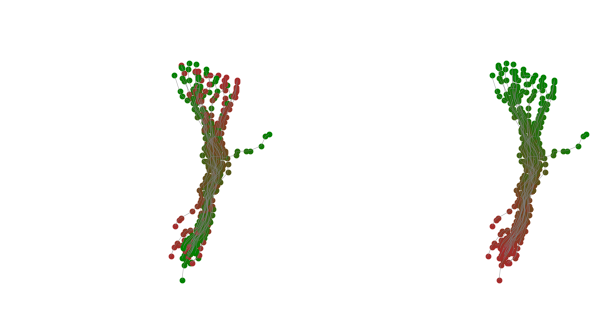

In [7]:
nb_streamline=20

s=1e1
axis=(0,2)
cmap1 = Color.interpolate(["brown", "green"],space='srgb')
pl.figure(figsize=(7.5,4))
pl.subplot(1,2,1)
for j in range(nb_streamline):
    m1=tract1.streamlines[j]
    nb_pts=m1.shape[0]
    for i in range(nb_pts):
        color1=cmap1(i/(nb_pts-1))
        pl.scatter(m1[i,axis[0]], m1[i,axis[1]],color=color1,s=s)
    pl.plot(m1[:,axis[0]], m1[:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-70,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis("off")

pl.subplot(1,2,2)
for j in range(nb_streamline):
    m2=tract2.streamlines[j]
    nb_pts=m2.shape[0]
    for i in range(nb_pts):
        color1=cmap1(i/(nb_pts-1))
        pl.scatter(m2[i,axis[0]], m2[i,axis[1]],color=color1,s=s)
    pl.plot(m2[:,axis[0]], m2[:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-70,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis('off')
#pl.savefig("/home/gui/Documents/Post-doc/Slides/Pastrami2025/figures/order_streamline.pdf",bbox_inches='tight')

# 24 Newgrid

In [8]:
n=40
cmd='cd .. && '
cmd+='cd preprocessing && '
cmd+='uv run compute_grid.py'
cmd+=' -i '+path+subject+'/05-Tracts/3reordered_CST_left.vtk'
cmd+=' -r '+path+'b0_aligned.nii.gz'
cmd+=' -n '+str(n)
cmd+=' -o '+path+subject+'/05-Tracts/4newgrid_CST_left_n'+str(n)+'.vtk'
print(cmd)
subprocess.run(cmd,shell=True);

cd .. && cd preprocessing && uv run compute_grid.py -i /home/gui/Documents/Post-doc/code/TractOT/data/000000/05-Tracts/3reordered_CST_left.vtk -r /home/gui/Documents/Post-doc/code/TractOT/data/b0_aligned.nii.gz -n 40 -o /home/gui/Documents/Post-doc/code/TractOT/data/000000/05-Tracts/4newgrid_CST_left_n40.vtk


[2026-05-21 14:20:46][dipy] WARNING: StatefulTractogram was previously saving in LPSMM space.
Use from_space=Space.LPSMM to load older files.
[2026-05-21 14:20:46][dipy] WARNING: Data_per_point has been modified.
[2026-05-21 14:20:46][dipy] WARNING: Data_per_streamline has been modified.
[2026-05-21 14:20:46][dipy] WARNING: Streamlines has been modified.


/home/gui/Documents/Post-doc/code/TractOT/.venv/lib/python3.12/site-packages/fury/colormap.py:234: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  orient = np.abs(np.divide(v, r, where=r != 0))


[2026-05-21 14:20:47][dipy] WARNING: StatefulTractogram was previously saving  in LPSMM space.
Now use to_space=Space.LPSMM to match the previous behavior.


In [9]:
tract1 = load_tractogram(
            path+subject+'/05-Tracts/3reordered_CST_left.vtk', 
            reference=path+'b0_aligned.nii.gz')

tract2 = load_tractogram(
            path+subject+'/05-Tracts/4newgrid_CST_left_n'+str(n)+'.vtk', 
            reference=path+'b0_aligned.nii.gz')

[2026-05-21 14:20:48][dipy] WARNING: StatefulTractogram was previously saving in LPSMM space.
Use from_space=Space.LPSMM to load older files.
[2026-05-21 14:20:48][dipy] WARNING: StatefulTractogram was previously saving in LPSMM space.
Use from_space=Space.LPSMM to load older files.


(np.float64(-70.0), np.float64(50.0), np.float64(-40.0), np.float64(80.0))

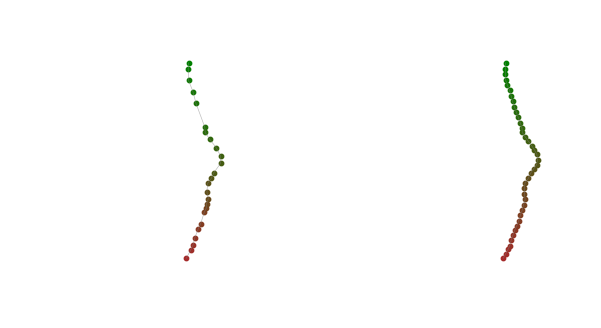

In [10]:
m1,m2=tract1.streamlines[0],tract2.streamlines[0]
nb_pts1,nb_pts2=m1.shape[0],m2.shape[0]

s=1e1
axis=(0,2)
cmap1 = Color.interpolate(["brown", "green"],space='srgb')
pl.figure(figsize=(7.5,4))
pl.subplot(1,2,1)
for i in range(nb_pts1):
    color1=cmap1(i/(nb_pts1-1))
    pl.scatter(m1[i,axis[0]], m1[i,axis[1]],color=color1,s=s)
pl.plot(m1[:,axis[0]], m1[:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-70,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis("off")

pl.subplot(1,2,2)
for i in range(nb_pts2):
    color1=cmap1(i/(nb_pts2-1))
    pl.scatter(m2[i,axis[0]], m2[i,axis[1]],color=color1,s=s)
pl.plot(m2[:,axis[0]], m2[:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-70,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis('off')
#pl.savefig("/home/gui/Documents/Post-doc/Slides/Pastrami2025/figures/newgrid_streamline.pdf",bbox_inches='tight')

# 25 Downsampling

In [11]:
c=30
cmd='cd .. && '
cmd+='cd preprocessing && '
cmd+='uv run down_sampling_spatial.py'
cmd+=' -i '+path+subject+'/05-Tracts/4newgrid_CST_left_n'+str(n)+'.vtk'
cmd+=' -r '+path+'b0_aligned.nii.gz'
cmd+=' -c '+str(c)
cmd+=' -o '+path+subject+'/05-Tracts/5downsampled_CST_left_n'+str(n)+'_c'+str(c)+'.vtk'
print(cmd)
subprocess.run(cmd,shell=True);

cd .. && cd preprocessing && uv run down_sampling_spatial.py -i /home/gui/Documents/Post-doc/code/TractOT/data/000000/05-Tracts/4newgrid_CST_left_n40.vtk -r /home/gui/Documents/Post-doc/code/TractOT/data/b0_aligned.nii.gz -c 30 -o /home/gui/Documents/Post-doc/code/TractOT/data/000000/05-Tracts/5downsampled_CST_left_n40_c30.vtk


[2026-05-21 14:20:50][dipy] WARNING: StatefulTractogram was previously saving in LPSMM space.
Use from_space=Space.LPSMM to load older files.
[2026-05-21 14:20:50][dipy] WARNING: Data_per_point has been modified.
[2026-05-21 14:20:50][dipy] WARNING: Data_per_streamline has been modified.
[2026-05-21 14:20:50][dipy] WARNING: Streamlines has been modified.
Obtained tracto has  965  streamlines
[2026-05-21 14:20:50][dipy] WARNING: StatefulTractogram was previously saving  in LPSMM space.
Now use to_space=Space.LPSMM to match the previous behavior.


/home/gui/Documents/Post-doc/code/TractOT/.venv/lib/python3.12/site-packages/fury/colormap.py:234: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  orient = np.abs(np.divide(v, r, where=r != 0))


[2026-05-21 14:20:52][dipy] WARNING: StatefulTractogram was previously saving in LPSMM space.
Use from_space=Space.LPSMM to load older files.
[2026-05-21 14:20:52][dipy] WARNING: StatefulTractogram was previously saving in LPSMM space.
Use from_space=Space.LPSMM to load older files.
12426 965


(np.float64(-10.0), np.float64(110.0), np.float64(-40.0), np.float64(80.0))

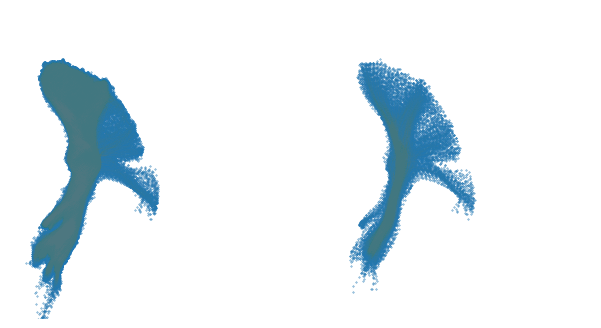

In [12]:
import sys
sys.path.append('../script/')
from from_vtk_to_numpy import vtk_to_numpy_tract_array

tract1 = load_tractogram(
            path+subject+'/05-Tracts/4newgrid_CST_left_n'+str(n)+'.vtk', 
            reference=path+'b0_aligned.nii.gz')

tract2 = load_tractogram(
            path+subject+'/05-Tracts/5downsampled_CST_left_n'+str(n)+'_c'+str(c)+'.vtk', 
            reference=path+'b0_aligned.nii.gz')

nb_streamline1,nb_streamline2=len(tract1.streamlines),len(tract2.streamlines)
print(nb_streamline1,nb_streamline2)
m1=vtk_to_numpy_tract_array(tract1,nb_streamline1)[0]
m2=vtk_to_numpy_tract_array(tract2,nb_streamline2)[0]

s=1e-1
axis=(0,2)
color='C0'
pl.figure(figsize=(7.5,4))
pl.subplot(1,2,1)
pl.scatter(m1[:,:,axis[0]], m1[:,:,axis[1]],color=color,s=s)
for i in range(nb_streamline1):
    pl.plot(m1[i,:,axis[0]], m1[i,:,axis[1]],linewidth=.1,color='grey',alpha=.1)
xmin,ymin,sq=-10,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis('off')

pl.subplot(1,2,2)
pl.scatter(m2[:,:,axis[0]], m2[:,:,axis[1]],color=color,s=s)
for i in range(nb_streamline2):
    pl.plot(m2[i,:,axis[0]], m2[i,:,axis[1]],linewidth=.1,color='grey',alpha=.1)
xmin,ymin,sq=-10,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis('off')
#pl.savefig("/home/gui/Documents/Post-doc/Slides/Pastrami2025/figures/downsampling_streamline1.png",bbox_inches='tight')

[2026-05-21 14:20:57][dipy] WARNING: StatefulTractogram was previously saving in LPSMM space.
Use from_space=Space.LPSMM to load older files.


(-40.0, 80.0)

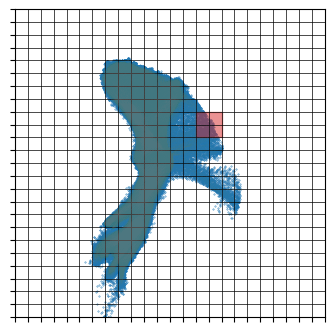

In [13]:
import matplotlib.patches as patches

tract1 = load_tractogram(
            path+subject+'/05-Tracts/4newgrid_CST_left_n'+str(n)+'.vtk', 
            reference=path+'b0_aligned.nii.gz')

nb_streamline1=len(tract1.streamlines)

m1=vtk_to_numpy_tract_array(tract1,nb_streamline1)[0]

s=1e-1
axis=(0,2)
color='C0'
fig = pl.figure(figsize=(4,4))
ax = fig.gca()
ax.set_xticks(np.arange(-75, 125, 5))
ax.set_yticks(np.arange(-45, 85., 5))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.xaxis.grid(linewidth=.5,color='black') 
ax.yaxis.grid(linewidth=.5,color='black')
pl.scatter(m1[:,:,axis[0]], m1[:,:,axis[1]],color=color,s=s)
for i in range(nb_streamline1):
    pl.plot(m1[i,:,axis[0]], m1[i,:,axis[1]],linewidth=.1,color='grey',alpha=.1)

rect = patches.Rectangle((40, 30), 10, 10, linewidth=1, edgecolor='C3', facecolor='C3',alpha=.5)
ax.add_patch(rect)
xmin,ymin,sq=-30,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
#pl.savefig("/home/gui/Documents/Post-doc/Slides/Pastrami2025/figures/downsampling_streamline2.png",bbox_inches='tight')

(30.0, 40.0)

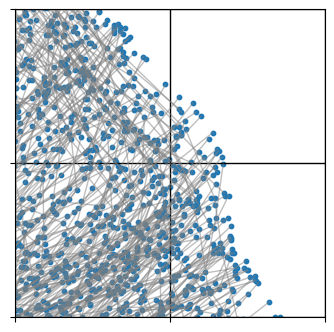

In [14]:
s=1e1
axis=(0,2)
color='C0'
fig = pl.figure(figsize=(4,4))
ax = fig.gca()
ax.set_xticks(np.arange(-75, 125, 5))
ax.set_yticks(np.arange(-45, 85., 5))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.xaxis.grid(linewidth=1,color='black') 
ax.yaxis.grid(linewidth=1,color='black')
pl.scatter(m1[:,:,axis[0]], m1[:,:,axis[1]],color=color,s=s)
for i in range(nb_streamline1):
    pl.plot(m1[i,:,axis[0]], m1[i,:,axis[1]],linewidth=1,color='grey',alpha=.5)
xmin,ymin,sq=40,30,10
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
#pl.savefig("/home/gui/Documents/Post-doc/Slides/Pastrami2025/figures/downsampling_streamline3.pdf",bbox_inches='tight')

(30.0, 40.0)

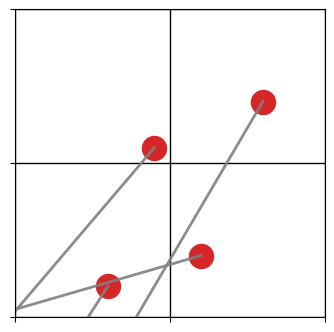

In [15]:
m3=np.zeros((4,2,2))
m3[0]=np.array([[-47,31],[-54,20]])
m3[1]=np.array([[-44,32],[-68,25]])
m3[2]=np.array([[-45.5,35.5],[-51,29]])
m3[3]=np.array([[-42,37],[-49,25]])
s=3e2
axis=(0,2)
color='C3'
fig = pl.figure(figsize=(4,4))
ax = fig.gca()
ax.set_xticks(np.arange(-75, 125, 5))
ax.set_yticks(np.arange(-45, 85., 5))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.xaxis.grid(linewidth=1,color='black') 
ax.yaxis.grid(linewidth=1,color='black')
pl.scatter(m3[:,:,0], m3[:,:,1],color=color,s=s)
for i in range(4):
    pl.plot(m3[i,:,0], m3[i,:,1],linewidth=2,color='grey',alpha=.9)
xmin,ymin,sq=-50,30,10
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
#pl.savefig("/home/gui/Documents/Post-doc/Slides/Pastrami2025/figures/downsampling_streamline4.pdf",bbox_inches='tight')